# 20b. Agent Framework Tradeoffs

**Tier:** Agents
**Estimated time:** 70 minutes
**Prerequisites:** 19 (agent loop from scratch), 20 (multi-agent patterns with LangGraph)
**Priority:** 🟡 Important — you will eventually be handed a codebase that picked CrewAI, or AutoGen, or the OpenAI Agents SDK, and need to know what that choice actually cost. *If skipped, revisit when:* evaluating which agent framework to adopt for a new project, or debugging an unfamiliar one.
**Source material:** CrewAI, AutoGen (`autogen-agentchat`), and the OpenAI Agents SDK — official docs and source; this repo's own notebooks 19 (raw Anthropic SDK loop) and 20 (LangGraph) as the two baselines.

## What You'll Learn
- The **same task, same model, same tool**, implemented five ways: raw SDK, LangGraph, CrewAI, AutoGen, and the OpenAI Agents SDK
- How to **measure** an agent framework rather than take its marketing at face value — real token counts and wall-clock time through a metering gateway, not self-reported numbers
- Why running third-party frameworks in **production** usually means isolating them — a real dependency conflict this notebook hits firsthand becomes the example

## Why This Matters
Notebook 19 taught you the raw loop; notebook 20 taught you LangGraph. Neither told you when to reach for something else. Every framework promises to make agents easier, but "easier" has a cost — usually paid in tokens, latency, or an opaque abstraction that fights your harness. The only way to see that cost honestly is to run the identical task through all of them and measure, which is exactly what this notebook does.

## 1. Setup

This notebook makes real, live LLM calls through a local metering gateway — every implementation below,
including the ones in an isolated environment, is measured by the same ground-truth token counter.

In [1]:
import os, sys, json, time, socket, subprocess, atexit, tempfile
from pathlib import Path

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

import httpx

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # production default: claude-opus-4-8
print("ANTHROPIC_API_KEY present." if HAS_ANTHROPIC else "No ANTHROPIC_API_KEY — code below is built but live calls are skipped.")

WORK_DIR = Path(tempfile.mkdtemp(prefix="nb20b_"))

def find_repo_root(marker="pyproject.toml", start=None):
    """Search upward from cwd for the repo root. cwd varies by how the notebook was launched --
    the repo's own checks (tools/run_nb.py, .claude/checks/notebooks.sh) run from the repo root,
    while opening this notebook directly in Jupyter runs from its own directory (04_agents/)."""
    here = Path(start or ".").resolve()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    return here

REPO_ROOT = find_repo_root()
FRAMEWORKS_PYTHON = REPO_ROOT / ".venv-frameworks" / "bin" / "python"
HAS_FRAMEWORKS_VENV = FRAMEWORKS_PYTHON.exists()
print(f"Scratch dir: {WORK_DIR}")
print(f"Isolated frameworks venv found: {HAS_FRAMEWORKS_VENV}"
      + ("" if HAS_FRAMEWORKS_VENV else " -- run tools/setup_frameworks_venv.sh to build it"))

ANTHROPIC_API_KEY present.
Scratch dir: /var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/nb20b_tpnfu4z3
Isolated frameworks venv found: True


## 2. The isolation + metering architecture

Running a third-party framework "like production" means two things this notebook takes seriously rather
than hand-waving:

1. **Isolation.** CrewAI, AutoGen, and the OpenAI Agents SDK each pull their own dependency tree. Installing
   all three into this repo's main environment turned out to be a real conflict, not a hypothetical one —
   see section 6. So the three third-party frameworks run as **subprocesses against a separate
   `.venv-frameworks` environment** (built by `tools/setup_frameworks_venv.sh`), while the raw SDK and
   LangGraph baselines run in-kernel, exactly as notebooks 19 and 20 do.
2. **Metering.** Self-reported token counts differ in shape across frameworks (and some don't report them
   at all). Instead, every implementation — in-kernel or isolated — talks to a small local **metering
   gateway**: a FastAPI proxy that forwards to `api.anthropic.com` and logs the real `usage` block from every
   response. No framework can under- or over-report; the ground truth lives in one place.

```
notebook kernel (.venv)                          isolated worker (.venv-frameworks)
+-----------------------------+   subprocess     +------------------------------+
| raw SDK loop  (in-kernel)   |                  | run_crewai.py                |
| LangGraph loop (in-kernel)  |   ------------->  | run_autogen.py               |
| metering gateway (FastAPI)  |   <-------------  | run_openai_agents.py         |
+-----------------------------+   JSON result     +------------------------------+
         ^                                          ANTHROPIC_BASE_URL -> gateway
         |__________________________________________________|
                    all five talk ONLY to the gateway
```

A second detail makes this closer to a real production gateway: every implementation below is configured
with a **dummy API key**. The gateway holds the real `ANTHROPIC_API_KEY` and substitutes it into the
`x-api-key` header on the way out — no framework, in-kernel or isolated, ever sees the real credential.

In [2]:
GATEWAY_SOURCE = '''
import os, json, time
from fastapi import FastAPI, Request
from fastapi.responses import Response
import httpx

app = FastAPI()
UPSTREAM = "https://api.anthropic.com"
REAL_API_KEY = os.environ["REAL_ANTHROPIC_API_KEY"]   # the only place the real key lives
USAGE_LOG = []

@app.get("/health")
def health():
    return {"status": "ok"}

@app.get("/usage")
def usage():
    return {"calls": USAGE_LOG}

@app.api_route("/{path:path}", methods=["GET", "POST"])
async def proxy(path: str, request: Request):
    # Every client below (in-kernel or isolated) is configured with a DUMMY key.
    # This gateway is the only thing that ever holds the real one.
    body = await request.body()
    headers = dict(request.headers)
    headers.pop("host", None)
    headers["x-api-key"] = REAL_API_KEY
    t0 = time.time()
    async with httpx.AsyncClient(timeout=90) as client:
        resp = await client.request(request.method, f"{UPSTREAM}/{path}",
                                     content=body, headers=headers,
                                     params=dict(request.query_params))
    entry = {"path": path, "status": resp.status_code, "elapsed": time.time() - t0}
    try:
        rjson = resp.json()
        u = rjson.get("usage")
        if u:
            entry["input_tokens"] = u.get("input_tokens", 0)
            entry["output_tokens"] = u.get("output_tokens", 0)
    except Exception:
        pass
    USAGE_LOG.append(entry)
    return Response(content=resp.content, status_code=resp.status_code,
                     media_type=resp.headers.get("content-type"))
'''

def find_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]

GATEWAY_PORT = find_free_port()
GATEWAY_URL = f"http://127.0.0.1:{GATEWAY_PORT}"
DUMMY_KEY = "gw-routed-no-real-key-here"   # every framework below uses this, never the real key
gateway_script = WORK_DIR / "gateway.py"
gateway_script.write_text(GATEWAY_SOURCE)

gateway_env = os.environ.copy()
gateway_env["REAL_ANTHROPIC_API_KEY"] = os.environ.get("ANTHROPIC_API_KEY", "")
gateway_proc = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "gateway:app", "--host", "127.0.0.1",
     "--port", str(GATEWAY_PORT), "--log-level", "warning"],
    cwd=str(WORK_DIR), env=gateway_env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
atexit.register(gateway_proc.terminate)   # safety net if the explicit cleanup cell is skipped

def wait_for_health(url, timeout_s=15):
    deadline = time.time() + timeout_s
    while time.time() < deadline:
        try:
            httpx.get(f"{url}/health", timeout=0.5)
            return True
        except Exception:
            time.sleep(0.3)
    return False

HAS_GATEWAY = HAS_ANTHROPIC and wait_for_health(GATEWAY_URL)
print(f"Gateway healthy at {GATEWAY_URL}: {HAS_GATEWAY}")

def gateway_call_count():
    """Current number of logged calls -- used as a before/after checkpoint per framework."""
    return len(httpx.get(f"{GATEWAY_URL}/usage").json()["calls"]) if HAS_GATEWAY else 0

def gateway_calls_since(checkpoint):
    calls = httpx.get(f"{GATEWAY_URL}/usage").json()["calls"] if HAS_GATEWAY else []
    return calls[checkpoint:]

Gateway healthy at http://127.0.0.1:64293: True


## 3. The shared task

One tool, one question, run identically (as identically as five different APIs allow) across all five
implementations: a `search_docs` tool over a tiny in-memory knowledge base pulled from this repo's own
notebook 05b, and a question that requires calling the tool before it can be answered correctly.

In [3]:
KB = {
    "gqa": "Grouped-Query Attention (GQA) reduces the KV cache by sharing one Key/Value head across a "
           "group of query heads. With 8 KV-head groups instead of 32 full heads, GQA cuts KV-cache "
           "memory by 4x compared to standard multi-head attention.",
    "moe": "Mixture of Experts (MoE) layers use a router to send each token to only a few of many expert "
           "feed-forward networks. Mixtral-8x7B has 8 experts and routes each token to its top 2, so only "
           "about 13B of its 47B total parameters are active per token.",
    "rope": "Rotary Position Embeddings (RoPE) encode position by rotating query and key vectors by an "
            "angle proportional to their position. This makes the attention score between two tokens "
            "depend only on their relative distance, not their absolute positions.",
}

QUESTION = ("Using the docs, explain why GQA saves memory and give the exact multiplier "
            "for 8 groups vs 32 heads.")

kb_path = WORK_DIR / "kb.json"
kb_path.write_text(json.dumps(KB))

def search_docs_impl(query: str) -> str:
    """The tool's actual logic -- reused (copy-pasted, since each framework needs its own
    in-process or subprocess copy) by every implementation below so the task is identical."""
    q = query.lower()
    for key, text in KB.items():
        if key in q or any(w in text.lower() for w in q.split()):
            return text
    return "no matching document found"

def check_correct(answer):
    """Did the answer actually land on 4x? Simple, objective grading for this task."""
    a = (answer or "").lower()
    return any(phrase in a for phrase in ["4x", "4-fold", "four times", "four-fold", "4 x"])

print("Question:", QUESTION)
print("KB topics:", list(KB.keys()))

Question: Using the docs, explain why GQA saves memory and give the exact multiplier for 8 groups vs 32 heads.
KB topics: ['gqa', 'moe', 'rope']


## 4. Baseline 1 — raw Anthropic SDK (in-kernel)

The manual tool-use loop from notebook 19, pointed at the gateway instead of `api.anthropic.com` directly.

In [4]:
import anthropic

RAW_SDK_TOOLS = [{
    "name": "search_docs",
    "description": "Search the internal docs for a query. Returns the best-matching document text.",
    "input_schema": {"type": "object", "properties": {"query": {"type": "string"}}, "required": ["query"]},
}]

def run_raw_sdk():
    client = anthropic.Anthropic(api_key=DUMMY_KEY, base_url=GATEWAY_URL)
    messages = [{"role": "user", "content": QUESTION}]
    while True:
        resp = client.messages.create(model=TEACH_MODEL, max_tokens=250,
                                       tools=RAW_SDK_TOOLS, messages=messages)
        if resp.stop_reason != "tool_use":
            return next(b.text for b in resp.content if b.type == "text")
        messages.append({"role": "assistant", "content": resp.content})
        results = [{"type": "tool_result", "tool_use_id": b.id, "content": search_docs_impl(b.input["query"])}
                   for b in resp.content if b.type == "tool_use"]
        messages.append({"role": "user", "content": results})

results = {}
if HAS_GATEWAY:
    checkpoint = gateway_call_count()
    t0 = time.time()
    answer = run_raw_sdk()
    elapsed = time.time() - t0
    calls = gateway_calls_since(checkpoint)
    results["Raw SDK"] = {
        "answer": answer, "elapsed": elapsed,
        "input_tokens": sum(c.get("input_tokens", 0) for c in calls),
        "output_tokens": sum(c.get("output_tokens", 0) for c in calls),
        "api_calls": len(calls), "loc": None, "isolated": False,
    }
    print("Raw SDK answer:", answer[:200])
else:
    results["Raw SDK"] = {"answer": None, "elapsed": None, "input_tokens": 0, "output_tokens": 0,
                           "api_calls": 0, "loc": None, "isolated": False}
    print("[skipped: no ANTHROPIC_API_KEY]")

Raw SDK answer: Based on the docs, here's the explanation:

## Why GQA Saves Memory

**Grouped-Query Attention (GQA) reduces the KV cache by sharing one Key/Value head across a group of query heads.** Instead of main


## 5. Baseline 2 — LangGraph (in-kernel)

A hand-built 2-node `StateGraph`, matching notebook 20's own pattern rather than the (now-deprecated in
this LangGraph version) `create_react_agent` prebuilt helper.

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

LANGGRAPH_TOOL_SCHEMA = RAW_SDK_TOOLS   # identical schema, reused

class GraphState(TypedDict):
    messages: Annotated[list, add_messages]

def build_langgraph():
    llm = ChatAnthropic(model=TEACH_MODEL, max_tokens=250, api_key=DUMMY_KEY,
                         base_url=GATEWAY_URL).bind_tools(LANGGRAPH_TOOL_SCHEMA)

    def call_model(state):
        return {"messages": [llm.invoke(state["messages"])]}

    def call_tools(state):
        last = state["messages"][-1]
        outputs = [ToolMessage(content=search_docs_impl(tc["args"]["query"]), tool_call_id=tc["id"])
                   for tc in last.tool_calls]
        return {"messages": outputs}

    def route(state):
        last = state["messages"][-1]
        return "tools" if getattr(last, "tool_calls", None) else END

    graph = StateGraph(GraphState)
    graph.add_node("agent", call_model)
    graph.add_node("tools", call_tools)
    graph.add_edge(START, "agent")
    graph.add_conditional_edges("agent", route, {"tools": "tools", END: END})
    graph.add_edge("tools", "agent")
    return graph.compile()

if HAS_GATEWAY:
    checkpoint = gateway_call_count()
    compiled_graph = build_langgraph()
    t0 = time.time()
    result = compiled_graph.invoke({"messages": [HumanMessage(content=QUESTION)]})
    elapsed = time.time() - t0
    answer = result["messages"][-1].content
    calls = gateway_calls_since(checkpoint)
    results["LangGraph"] = {
        "answer": answer, "elapsed": elapsed,
        "input_tokens": sum(c.get("input_tokens", 0) for c in calls),
        "output_tokens": sum(c.get("output_tokens", 0) for c in calls),
        "api_calls": len(calls), "loc": None, "isolated": False,
    }
    print("LangGraph answer:", answer[:200])
else:
    results["LangGraph"] = {"answer": None, "elapsed": None, "input_tokens": 0, "output_tokens": 0,
                             "api_calls": 0, "loc": None, "isolated": False}
    print("[skipped: no ANTHROPIC_API_KEY]")

LangGraph answer: Based on the documentation:

## Why GQA Saves Memory

**Grouped-Query Attention (GQA)** saves memory by **sharing one Key/Value head across a group of query heads**. Rather than maintaining separate k


## 6. Three isolated frameworks — CrewAI, AutoGen, OpenAI Agents SDK

Installing `crewai` into this repo's own `.venv` turns out to be impossible without downgrading half the
repo: `crewai` requires `rich<15`, this repo pins `rich>=15.0.0` (used by `ragkit.pretty` for every RAG
notebook's display helpers), and a from-scratch dependency resolution that includes `crewai` drags `torch`,
`transformers`, and `chromadb` to different versions across every other notebook. That conflict is real —
verified with `uv pip compile`, not assumed — and it is exactly the kind of thing that forces isolation in
a real production system, not just in this notebook. `tools/setup_frameworks_venv.sh` builds a **separate**
`.venv-frameworks` with `crewai`, `autogen-agentchat`, `autogen-ext[anthropic]`, and `openai-agents[litellm]`
— 146 packages, zero conflicts, none of which ever touch the main `.venv`.

Each framework below runs as a real OS subprocess against that separate interpreter, writing its runner
script to `WORK_DIR` first (same subprocess-plus-readback pattern as notebook 07b's distributed workers).

In [6]:
CREWAI_RUNNER = '''
import os, sys, json, time
from crewai import LLM, Agent, Task, Crew
from crewai.tools import tool

KB = json.load(open(os.environ["KB_PATH"]))

@tool("search_docs")
def search_docs(query: str) -> str:
    "Search the internal docs for a query. Returns the best-matching document text."
    q = query.lower()
    for key, text in KB.items():
        if key in q or any(w in text.lower() for w in q.split()):
            return text
    return "no matching document found"

llm = LLM(model=f"anthropic/{os.environ['TEACH_MODEL']}", max_tokens=250)
agent = Agent(role="Research Assistant", goal="Answer questions using search_docs",
              backstory="You always search before answering.", llm=llm, tools=[search_docs], verbose=False)
task = Task(description=os.environ["QUESTION"], expected_output="A short, precise answer with the multiplier.",
            agent=agent)
crew = Crew(agents=[agent], tasks=[task], verbose=False, tracing=False)

t0 = time.time()
result = crew.kickoff()
elapsed = time.time() - t0

with open(os.environ["OUT_PATH"], "w") as f:
    json.dump({"framework": "CrewAI", "answer": str(result), "elapsed": elapsed}, f)
'''

AUTOGEN_RUNNER = '''
import os, sys, json, time, asyncio
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.anthropic import AnthropicChatCompletionClient

KB = json.load(open(os.environ["KB_PATH"]))

def search_docs(query: str) -> str:
    "Search the internal docs for a query. Returns the best-matching document text."
    q = query.lower()
    for key, text in KB.items():
        if key in q or any(w in text.lower() for w in q.split()):
            return text
    return "no matching document found"

async def main():
    client = AnthropicChatCompletionClient(
        model=os.environ["TEACH_MODEL"],
        api_key=os.environ["ANTHROPIC_API_KEY"],
        base_url=os.environ["ANTHROPIC_BASE_URL"],
        max_tokens=250,
        # This exact model string isn't in autogen-ext's built-in registry yet, so its
        # capabilities have to be declared explicitly rather than looked up by name.
        model_info={"vision": False, "function_calling": True, "json_output": True,
                    "family": "claude-3-5-sonnet", "structured_output": False,
                    "multiple_system_messages": False},
    )
    agent = AssistantAgent("research_assistant", model_client=client, tools=[search_docs],
                            system_message="You always search docs before answering.")
    t0 = time.time()
    result = await agent.run(task=os.environ["QUESTION"])
    elapsed = time.time() - t0
    final_text = result.messages[-1].content
    await client.close()

    with open(os.environ["OUT_PATH"], "w") as f:
        json.dump({"framework": "AutoGen", "answer": str(final_text), "elapsed": elapsed}, f)

asyncio.run(main())
'''

OPENAI_AGENTS_RUNNER = '''
import os, sys, json, time, asyncio
from agents import Agent, Runner, function_tool, set_tracing_disabled
from agents.extensions.models.litellm_model import LitellmModel

set_tracing_disabled(True)   # no export to platform.openai.com -- stay fully local
KB = json.load(open(os.environ["KB_PATH"]))

@function_tool
def search_docs(query: str) -> str:
    "Search the internal docs for a query. Returns the best-matching document text."
    q = query.lower()
    for key, text in KB.items():
        if key in q or any(w in text.lower() for w in q.split()):
            return text
    return "no matching document found"

async def main():
    model = LitellmModel(model=f"anthropic/{os.environ['TEACH_MODEL']}",
                          base_url=os.environ["ANTHROPIC_BASE_URL"],
                          api_key=os.environ["ANTHROPIC_API_KEY"])
    agent = Agent(name="research_assistant", instructions="You always search docs before answering.",
                  model=model, tools=[search_docs])
    t0 = time.time()
    result = await Runner.run(agent, os.environ["QUESTION"])
    elapsed = time.time() - t0

    with open(os.environ["OUT_PATH"], "w") as f:
        json.dump({"framework": "OpenAI Agents SDK", "answer": str(result.final_output), "elapsed": elapsed}, f)

asyncio.run(main())
'''

runner_paths = {}
for name, source in [("crewai", CREWAI_RUNNER), ("autogen", AUTOGEN_RUNNER), ("openai_agents", OPENAI_AGENTS_RUNNER)]:
    p = WORK_DIR / f"run_{name}.py"
    p.write_text(source)
    runner_paths[name] = p
print("Runner scripts written:", list(runner_paths.values()))

Runner scripts written: [PosixPath('/var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/nb20b_tpnfu4z3/run_crewai.py'), PosixPath('/var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/nb20b_tpnfu4z3/run_autogen.py'), PosixPath('/var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/nb20b_tpnfu4z3/run_openai_agents.py')]


In [7]:
def run_isolated_framework(framework_key, script_path, timeout_s=120):
    """Launch one framework as a real subprocess against .venv-frameworks, pointed at the
    same gateway as everything else. Returns (result_dict, source_lines_of_code)."""
    out_path = WORK_DIR / f"{framework_key}_out.json"
    env = os.environ.copy()
    env.update(
        ANTHROPIC_API_KEY=DUMMY_KEY,          # dummy -- the gateway injects the real key
        ANTHROPIC_BASE_URL=GATEWAY_URL,       # native-SDK-routed frameworks read this env var
        TEACH_MODEL=TEACH_MODEL,
        KB_PATH=str(kb_path),
        QUESTION=QUESTION,
        OUT_PATH=str(out_path),
        CREWAI_TRACING_ENABLED="false",       # keep CrewAI fully headless, no console prompt
    )
    proc = subprocess.Popen([str(FRAMEWORKS_PYTHON), str(script_path)], env=env,
                             stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    atexit.register(proc.terminate)
    try:
        stdout, _ = proc.communicate(timeout=timeout_s)
    except subprocess.TimeoutExpired:
        proc.kill()
        return {"answer": None, "elapsed": None, "outcome": f"[timeout after {timeout_s}s]"}, len(script_path.read_text().splitlines())

    loc = len(script_path.read_text().splitlines())
    if proc.returncode != 0 or not out_path.exists():
        tail = stdout.decode(errors="replace")[-500:]
        return {"answer": None, "elapsed": None, "outcome": f"[failed: {tail}]"}, loc
    return json.loads(out_path.read_text()), loc

FRAMEWORK_RUNNERS = [
    ("CrewAI", "crewai"),
    ("AutoGen", "autogen"),
    ("OpenAI Agents SDK", "openai_agents"),
]

for label, key in FRAMEWORK_RUNNERS:
    if not (HAS_GATEWAY and HAS_FRAMEWORKS_VENV):
        reason = "no ANTHROPIC_API_KEY" if not HAS_GATEWAY else ".venv-frameworks not found -- run tools/setup_frameworks_venv.sh"
        results[label] = {"answer": None, "elapsed": None, "input_tokens": 0, "output_tokens": 0,
                           "api_calls": 0, "loc": None, "isolated": True, "outcome": f"[skipped: {reason}]"}
        print(f"{label}: [skipped: {reason}]")
        continue
    checkpoint = gateway_call_count()
    run_result, loc = run_isolated_framework(key, runner_paths[key])
    calls = gateway_calls_since(checkpoint)
    results[label] = {
        "answer": run_result.get("answer"), "elapsed": run_result.get("elapsed"),
        "input_tokens": sum(c.get("input_tokens", 0) for c in calls),
        "output_tokens": sum(c.get("output_tokens", 0) for c in calls),
        "api_calls": len(calls), "loc": loc, "isolated": True,
        "outcome": run_result.get("outcome", "ok"),
    }
    preview = str(run_result.get("answer"))[:150]
    print(f"{label}: {preview}")

CrewAI: ## Final Answer

**Why GQA Saves Memory:**
Grouped-Query Attention (GQA) reduces the KV cache by sharing one Key/Value head across a group of query he


AutoGen: Grouped-Query Attention (GQA) reduces the KV cache by sharing one Key/Value head across a group of query heads. With 8 KV-head groups instead of 32 fu


OpenAI Agents SDK: Based on the docs, here's the explanation:

## Why GQA Saves Memory

**GQA (Grouped Query Attention) reduces the KV cache by sharing one Key/Value hea


## 7. Results — measured, not claimed

Every row's tokens come from the gateway's own record of the real `usage` block in each response — not
from what the framework says it used.

In [8]:
HAIKU_INPUT_PER_MTOK = 1.00    # claude-haiku-4-5 pricing, $/1M input tokens
HAIKU_OUTPUT_PER_MTOK = 5.00   # $/1M output tokens

# Fill in in-kernel LOC by measuring this notebook's own implementation cells.
import inspect
results["Raw SDK"]["loc"] = len(inspect.getsource(run_raw_sdk).splitlines())
results["LangGraph"]["loc"] = len(inspect.getsource(build_langgraph).splitlines())

rows = []
for name, r in results.items():
    cost = (r["input_tokens"] / 1e6) * HAIKU_INPUT_PER_MTOK + (r["output_tokens"] / 1e6) * HAIKU_OUTPUT_PER_MTOK
    correct = check_correct(r["answer"]) if r["answer"] else None
    rows.append({
        "framework": name,
        "isolated": r["isolated"],
        "wall_clock_s": round(r["elapsed"], 2) if r["elapsed"] is not None else None,
        "input_tokens": r["input_tokens"],
        "output_tokens": r["output_tokens"],
        "api_calls": r["api_calls"],
        "cost_usd": round(cost, 5),
        "loc": r["loc"],
        "correct": correct,
        "outcome": r.get("outcome", "ok" if r["answer"] else "[skipped]"),
    })

import pandas as pd
df = pd.DataFrame(rows).set_index("framework")
print(df.to_string())

                   isolated  wall_clock_s  input_tokens  output_tokens  api_calls  cost_usd  loc  correct outcome
framework                                                                                                        
Raw SDK               False          4.26          1517            334          2   0.00319   12     True      ok
LangGraph             False          3.71          1494            283          2   0.00291   24     True      ok
CrewAI                 True          4.20          1779            309          2   0.00332   29     True      ok
AutoGen                True          1.31           615             61          1   0.00092   39     True      ok
OpenAI Agents SDK      True          3.66          1538            329          2   0.00318   31     True      ok


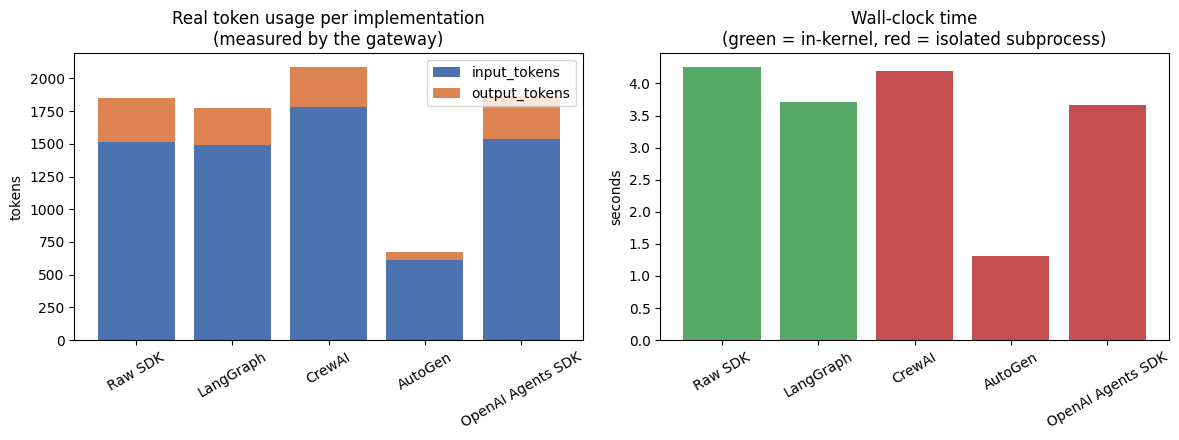

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

plot_df = df[df["wall_clock_s"].notna()]
if len(plot_df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    bottom = [0] * len(plot_df)
    for col, color in [("input_tokens", "#4C72B0"), ("output_tokens", "#DD8452")]:
        ax1.bar(plot_df.index, plot_df[col], bottom=bottom, label=col, color=color)
        bottom = [b + v for b, v in zip(bottom, plot_df[col])]
    ax1.set_ylabel("tokens")
    ax1.set_title("Real token usage per implementation\n(measured by the gateway)")
    ax1.legend()
    ax1.tick_params(axis="x", rotation=30)

    colors = ["#55A868" if not iso else "#C44E52" for iso in plot_df["isolated"]]
    ax2.bar(plot_df.index, plot_df["wall_clock_s"], color=colors)
    ax2.set_ylabel("seconds")
    ax2.set_title("Wall-clock time\n(green = in-kernel, red = isolated subprocess)")
    ax2.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()
else:
    print("No live results to plot (offline run).")

*Same task, same model, same tool — the token and latency spread across implementations is the abstraction cost, made visible instead of assumed.*

## 8. Reading the results honestly

A few things worth calling out about what the numbers actually mean, independent of whatever they show on
a given run (LLM output length varies run to run — rerun the notebook and expect the ranking of "most
verbose" to hold roughly steady even as exact token counts shift):

- **Raw SDK and LangGraph** are the floor: you wrote every token of the prompt and every line of control
  flow. Nothing is hidden, so there's nothing to be surprised by.
- **CrewAI** models roles and backstories (`Agent(role=..., goal=..., backstory=...)`), and that framing
  becomes literal prompt text on every call — the tradeoff is a higher token floor for a more structured way
  to describe multi-agent teams.
- **AutoGen** and **OpenAI Agents SDK** sit closer to the raw-SDK shape (a model client plus a tool list),
  which tends to show up as fewer or shorter extra tokens than CrewAI's role-based framing.
- **`api_calls`** matters as much as raw token count: a framework that resolves the tool call in one round
  trip is doing less redundant context-resending than one that needs an extra turn.
- **`loc`** (lines of code) is a real but narrow proxy for "how much do I own." A framework with fewer LOC
  in the runner script isn't necessarily simpler overall — it may just have pushed complexity into the
  library you didn't write and now have to debug when it breaks.

**Decision guide:**

| Reach for... | When |
|---|---|
| **Raw SDK** (19) | You need to see and control every token; the harness (21) IS the product |
| **LangGraph** (20) | Control flow branches — parallel fan-out, conditional routing, cycles |
| **CrewAI** | The problem is naturally role-shaped (a "team" of specialists) and you want that structure free |
| **AutoGen** | Multi-agent conversations where agents need to talk to each other, not just to you |
| **OpenAI Agents SDK** | You want a minimal agent/tool abstraction without LangGraph's graph model |

The deeper point, tying back to notebook 21 (harness engineering) and 23 (loop engineering): a framework is
a **harness someone else wrote**. It fits your loop until the day it doesn't — and the day it doesn't is
exactly when you're glad you also know how to write the raw loop yourself.

## 9. The dependency footprint is itself a tradeoff

This notebook is the concrete example. `crewai` requires `rich<15`; this repo's `pyproject.toml` pins
`rich>=15.0.0` because `ragkit.pretty` (used across every RAG notebook in `07_rag_learning/`) needs a
recent `rich` API. Running `uv pip compile` with all three frameworks added to the main environment doesn't
just fail on that one constraint — it also wants to move `torch` 2.10→2.13, `transformers` 5.10→5.14, and
`anthropic` up several minor versions to satisfy the combined graph, touching every other notebook in the
curriculum. That's not a hypothetical "frameworks add dependency weight" warning; it's a version conflict
that actually blocked installation, resolved by giving these three frameworks their own environment
(`.venv-frameworks`) and talking to them over a subprocess boundary — the same isolation technique real
production systems use when two services need incompatible dependency graphs.

## 10. Cleanup

In [10]:
gateway_proc.terminate()
try:
    gateway_proc.wait(timeout=5)
except subprocess.TimeoutExpired:
    gateway_proc.kill()
print(f"Gateway process exit code: {gateway_proc.poll()}")

Gateway process exit code: -15


## Exercises

In [11]:
# Exercise 1 (Warm-up): Add a second question and compare tool-call counts.
# Task: Pick a QUESTION that needs BOTH the "moe" and "rope" docs to answer fully (e.g. asking
#       about MoE routing AND positional encoding in one question). Run it through run_raw_sdk()
#       and see whether the model calls search_docs once per topic or tries to answer from one call.
# Hint: reuse run_raw_sdk() -- it already loops until stop_reason != "tool_use".

# YOUR CODE HERE

In [12]:
# Exercise 2 (Apply): Add real per-framework isolation for a FOURTH implementation.
# Task: Write a minimal LlamaIndex (or Haystack, or Semantic Kernel) runner in the same shape as
#       CREWAI_RUNNER -- read KB_PATH/QUESTION/OUT_PATH from env, point at ANTHROPIC_BASE_URL with
#       the dummy key, write a JSON result. You do NOT need to install it into .venv-frameworks to
#       write the runner script -- just show what the isolation boundary would look like.
# Hint: copy AUTOGEN_RUNNER as your starting template; it's the shortest of the three.

# YOUR CODE HERE

In [13]:
# Exercise 3 (Extend): Turn the correctness check into a rubric-scored eval.
# Task: Notebook 26 (LLM-as-judge) scores answers on a rubric instead of a keyword match. Write a
#       judge_answer(answer) function that scores 0-2 on: (a) mentions GQA shares KV heads across
#       query-head groups, (b) states the exact 4x multiplier. Apply it to every framework's
#       "answer" in `results` and add a "rubric_score" column to the results table.
# Hint: check_correct() already does the keyword version of (b) -- extend it, or call the real
#       TEACH_MODEL through the gateway as an actual judge (notebook 26's pattern).

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1
MULTI_TOPIC_QUESTION = ("Using the docs, explain both how MoE routing decides which expert handles "
                         "a token, and why RoPE encodes position as a rotation instead of an addition.")
checkpoint = gateway_call_count()
old_question, QUESTION = QUESTION, MULTI_TOPIC_QUESTION
answer = run_raw_sdk()
QUESTION = old_question
calls = gateway_calls_since(checkpoint)
print(f"{len(calls)} API calls for a 2-topic question")
print(answer[:300])
# Typically 3 calls: one that emits (up to) two parallel tool_use blocks for "moe" and "rope",
# one tool_result turn, then the final synthesis -- fewer than 2 calls per topic because
# parallel tool use lets Claude ask for both docs in a single turn.

# Exercise 2 -- a LlamaIndex-shaped runner (not installed, but the isolation shape is the point)
LLAMAINDEX_RUNNER_SKETCH = """
import os, json, time
from llama_index.llms.anthropic import Anthropic
from llama_index.core.tools import FunctionTool
from llama_index.core.agent import ReActAgent

KB = json.load(open(os.environ["KB_PATH"]))

def search_docs(query: str) -> str:
    q = query.lower()
    for key, text in KB.items():
        if key in q or any(w in text.lower() for w in q.split()):
            return text
    return "no matching document found"

llm = Anthropic(model=os.environ["TEACH_MODEL"], api_key=os.environ["ANTHROPIC_API_KEY"],
                 base_url=os.environ["ANTHROPIC_BASE_URL"])
agent = ReActAgent.from_tools([FunctionTool.from_defaults(fn=search_docs)], llm=llm)
t0 = time.time()
answer = agent.chat(os.environ["QUESTION"])
elapsed = time.time() - t0
json.dump({"framework": "LlamaIndex", "answer": str(answer), "elapsed": elapsed},
          open(os.environ["OUT_PATH"], "w"))
"""
print(LLAMAINDEX_RUNNER_SKETCH)
# The shape is identical to AUTOGEN_RUNNER: env-var-driven config, dummy key, gateway base_url,
# JSON result written to OUT_PATH -- that consistency IS the isolation boundary's whole point.

# Exercise 3
def judge_answer(answer):
    if not answer:
        return 0
    a = answer.lower()
    score = 0
    if "kv" in a and ("shar" in a or "group" in a):
        score += 1
    if check_correct(answer):
        score += 1
    return score

df["rubric_score"] = [judge_answer(results[name]["answer"]) for name in df.index]
print(df[["correct", "rubric_score"]].to_string())
# A real rubric-scored eval (notebook 26's pattern) would call TEACH_MODEL as an independent judge
# rather than keyword-matching -- worth doing if this comparison becomes a recurring benchmark.
```
</details>

## Key Takeaways
- The same task implemented five ways shows the real cost of each abstraction level — **measured through
  a shared metering gateway**, not self-reported by any framework.
- **Isolation is a real production concern, not a hypothetical one**: `crewai`'s `rich<15` requirement
  genuinely conflicts with this repo's `rich>=15.0.0`, resolved the same way production systems resolve
  incompatible dependency graphs — a separate environment and a subprocess boundary.
- A metering gateway that **substitutes the real API key server-side** means no framework, in-kernel or
  isolated, ever holds the real credential — the same pattern a production AI gateway uses (ties to
  notebook 32's cost-engineering framing).
- **CrewAI's role-based framing costs real tokens**; AutoGen and the OpenAI Agents SDK stay closer to the
  raw-SDK token floor. Neither is "wrong" — they're trading tokens for a different mental model.
- A framework is a harness someone else wrote. It fits your loop until it doesn't — which is exactly why
  notebooks 19 (raw loop) and 21 (harness engineering) are worth knowing even after you've picked a
  framework.

## What's Next
Notebook **21 — Harness Engineering** goes deeper on the idea underlying this whole comparison: the
harness *is* the product, whether you write it yourself or inherit one from a framework.